# Predicting Fraud Risk Through Authentication and Transaction Behavior in Digital Banking

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

In [3]:
# Load the dataset
df = pd.read_csv("banking_transactions.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,"17,829.010",4,12.000,13,0.370,2354,22,25,"112,760.070",63,3189,92,71.800,POS Terminal,OTP,1,1,1,False
1,1000002,"16,401.830",1,34.300,17,0.260,3181,17,15,"118,899.520",83,839,63,11.800,Web Banking,Biometric,0,0,1,False
2,1000003,"9,678.290",8,67.800,39,0.150,1390,3,2,"408,168.980",9,3938,80,35.700,ATM,OTP,1,0,1,False
3,1000004,"19,013.380",5,17.800,42,0.550,3716,16,6,"80,771.690",78,11111,11,74.800,Mobile App,OTP,1,1,0,False
4,1000005,"13,834.950",3,88.900,63,0.240,4694,16,10,"382,265.320",17,3171,87,0.000,Mobile App,OTP,1,0,0,False


In [5]:
# Basic dataset information

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['transaction_id', 'transaction_amount', 'login_attempts', 'device_risk_score', 'transfer_frequency', 'anomaly_score', 'account_age_days', 'transaction_time_hour', 'failed_transactions_last_30d', 'avg_monthly_balance', 'daily_transaction_count', 'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score', 'payment_channel', 'authentication_type', 'card_present_flag', 'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag']

Data types:
transaction_id                      int64
transaction_amount                float64
login_attempts                      int64
device_risk_score                 float64
transfer_frequency                  int64
anomaly_score                     float64
account_age_days                    int64
transaction_time_hour               int64
failed_transactions_last_30d        int64
avg_monthly_balance               float64
daily_transaction_count             int64
geo_distance_km                     int64
session_duration_m

transaction_id                    0
transaction_amount                0
login_attempts                    0
device_risk_score                 0
transfer_frequency                0
anomaly_score                     0
account_age_days                  0
transaction_time_hour             0
failed_transactions_last_30d      0
avg_monthly_balance               0
daily_transaction_count           0
geo_distance_km                   0
session_duration_minutes          0
transaction_velocity_score        0
payment_channel                   0
authentication_type               0
card_present_flag                 0
international_transaction_flag    0
suspicious_ip_flag                0
fraud_flag                        0
dtype: int64


Duplicate rows: 0


In [7]:
# Clean the dataset

# Convert fraud_flag to integer if it is currently True/False
df["fraud_flag"] = df["fraud_flag"].astype(int)

# Drop transaction_id because it is only an identifier and should not be used for prediction
if "transaction_id" in df.columns:
    df_model = df.drop(columns=["transaction_id"])
else:
    df_model = df.copy()

print("Cleaned dataset shape:", df_model.shape)
df_model.head()

Cleaned dataset shape: (10000, 19)


,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,"17,829.010",4,12.000,13,0.370,2354,22,25,"112,760.070",63,3189,92,71.800,POS Terminal,OTP,1,1,1,0
1,"16,401.830",1,34.300,17,0.260,3181,17,15,"118,899.520",83,839,63,11.800,Web Banking,Biometric,0,0,1,0
2,"9,678.290",8,67.800,39,0.150,1390,3,2,"408,168.980",9,3938,80,35.700,ATM,OTP,1,0,1,0
3,"19,013.380",5,17.800,42,0.550,3716,16,6,"80,771.690",78,11111,11,74.800,Mobile App,OTP,1,1,0,0
4,"13,834.950",3,88.900,63,0.240,4694,16,10,"382,265.320",17,3171,87,0.000,Mobile App,OTP,1,0,0,0


## Exploratory Data Analysis

This section explores fraud distribution, authentication methods, login attempts, suspicious IP activity, device risk, and other digital banking behaviors.

Fraud counts:
fraud_flag
0    8749
1    1251
Name: count, dtype: int64

Fraud rate: 12.51%


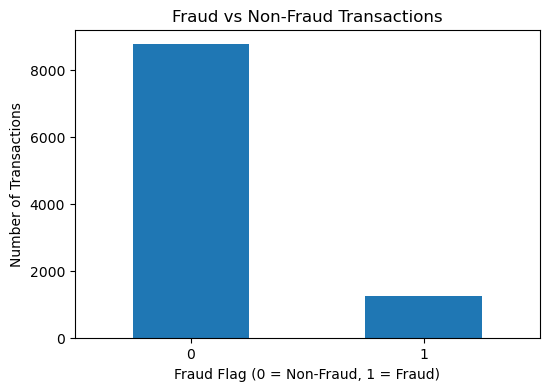

In [10]:
# Fraud distribution

fraud_counts = df_model["fraud_flag"].value_counts().sort_index()
fraud_rate = df_model["fraud_flag"].mean()

print("Fraud counts:")
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.2%}")

plt.figure(figsize=(6,4))
fraud_counts.plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Flag (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

,count,mean,fraud_rate_percent
authentication_type,,,
OTP,4214,0.131,13.075
Password Only,1817,0.128,12.768
Biometric,1585,0.121,12.050
Two-Factor Authentication,2384,0.116,11.619


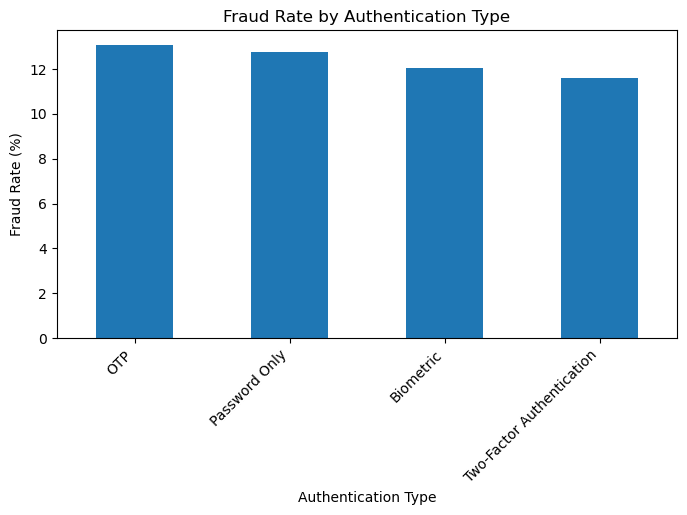

In [12]:
# Fraud rate by authentication type

auth_fraud = (
    df_model.groupby("authentication_type")["fraud_flag"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

auth_fraud["fraud_rate_percent"] = auth_fraud["mean"] * 100
display(auth_fraud)

plt.figure(figsize=(8,4))
auth_fraud["fraud_rate_percent"].plot(kind="bar")
plt.title("Fraud Rate by Authentication Type")
plt.xlabel("Authentication Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

,count,mean,fraud_rate_percent
payment_channel,,,
ATM,777,0.130,12.999
Mobile App,4804,0.128,12.823
Web Banking,3247,0.123,12.319
POS Terminal,1172,0.114,11.433


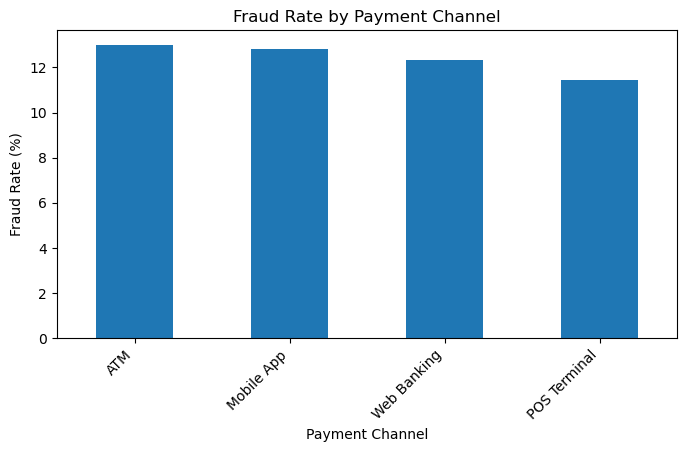

In [14]:
# Fraud rate by payment channel

channel_fraud = (
    df_model.groupby("payment_channel")["fraud_flag"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

channel_fraud["fraud_rate_percent"] = channel_fraud["mean"] * 100
display(channel_fraud)

plt.figure(figsize=(8,4))
channel_fraud["fraud_rate_percent"].plot(kind="bar")
plt.title("Fraud Rate by Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()


Fraud rate by suspicious_ip_flag:


,count,mean,fraud_rate_percent
suspicious_ip_flag,,,
0,4995,0.122,12.192
1,5005,0.128,12.827


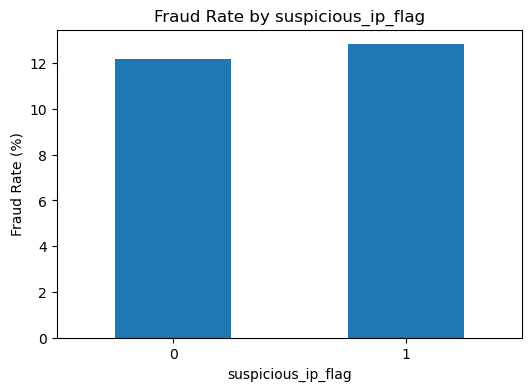


Fraud rate by international_transaction_flag:


,count,mean,fraud_rate_percent
international_transaction_flag,,,
0,5016,0.127,12.699
1,4984,0.123,12.319


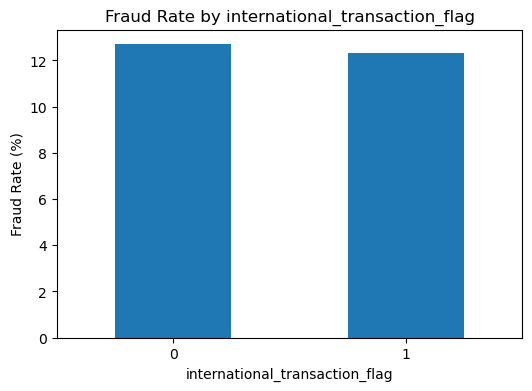


Fraud rate by card_present_flag:


,count,mean,fraud_rate_percent
card_present_flag,,,
0,5072,0.125,12.480
1,4928,0.125,12.541


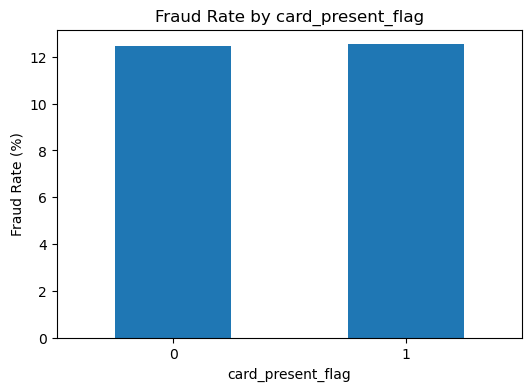

In [16]:
# Suspicious IP and international transaction fraud rates

binary_features = ["suspicious_ip_flag", "international_transaction_flag", "card_present_flag"]

for col in binary_features:
    summary = df_model.groupby(col)["fraud_flag"].agg(["count", "mean"])
    summary["fraud_rate_percent"] = summary["mean"] * 100
    print(f"\nFraud rate by {col}:")
    display(summary)

    plt.figure(figsize=(6,4))
    summary["fraud_rate_percent"].plot(kind="bar")
    plt.title(f"Fraud Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(rotation=0)
    plt.show()

In [18]:
# Compare numeric variables by fraud status

numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "fraud_flag"]

fraud_numeric_summary = df_model.groupby("fraud_flag")[numeric_cols].mean().T
fraud_numeric_summary.columns = ["Non-Fraud Average", "Fraud Average"]
fraud_numeric_summary["Difference"] = fraud_numeric_summary["Fraud Average"] - fraud_numeric_summary["Non-Fraud Average"]
fraud_numeric_summary = fraud_numeric_summary.sort_values("Difference", ascending=False)

display(fraud_numeric_summary)

,Non-Fraud Average,Fraud Average,Difference
transaction_amount,"12,398.004","12,515.911",117.907
transaction_velocity_score,50.016,50.862,0.846
session_duration_minutes,60.418,60.907,0.489
anomaly_score,0.288,0.772,0.483
suspicious_ip_flag,0.499,0.513,0.015
transaction_time_hour,11.553,11.558,0.005
card_present_flag,0.493,0.494,0.001
international_transaction_flag,0.499,0.491,-0.009
login_attempts,6.440,6.430,-0.010
device_risk_score,50.271,50.158,-0.113


<Figure size 600x400 with 0 Axes>

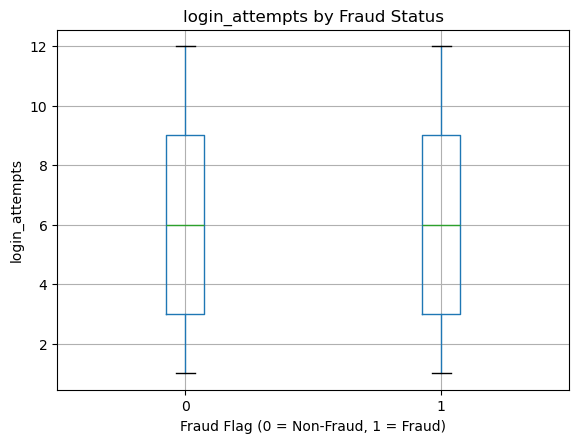

<Figure size 600x400 with 0 Axes>

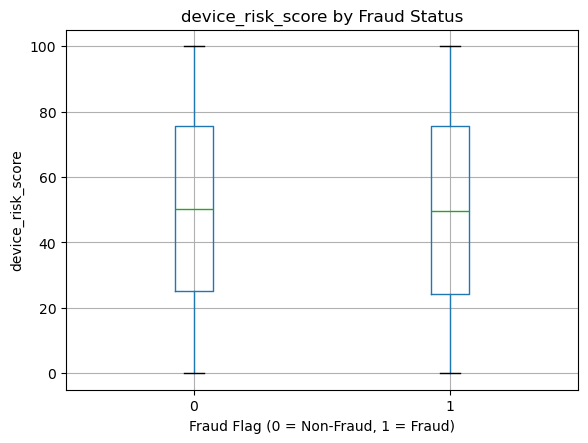

<Figure size 600x400 with 0 Axes>

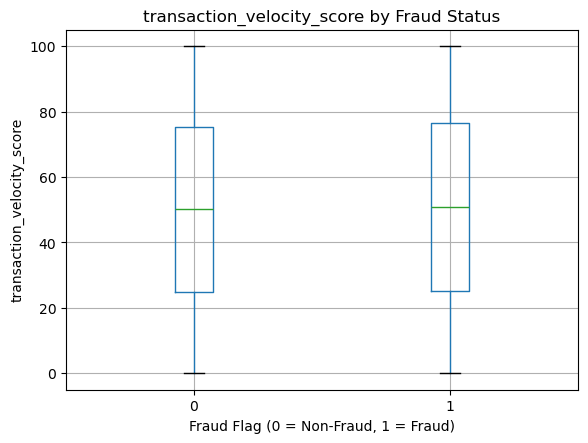

<Figure size 600x400 with 0 Axes>

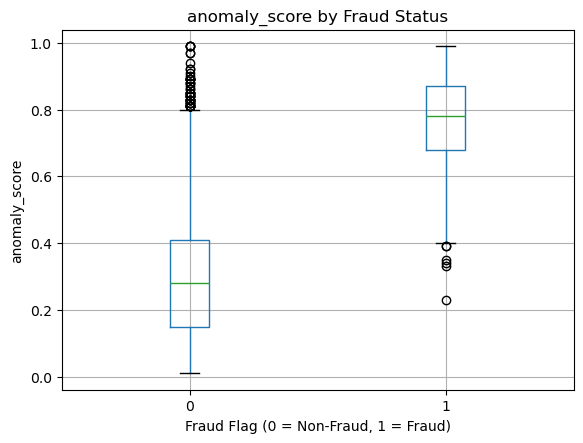

<Figure size 600x400 with 0 Axes>

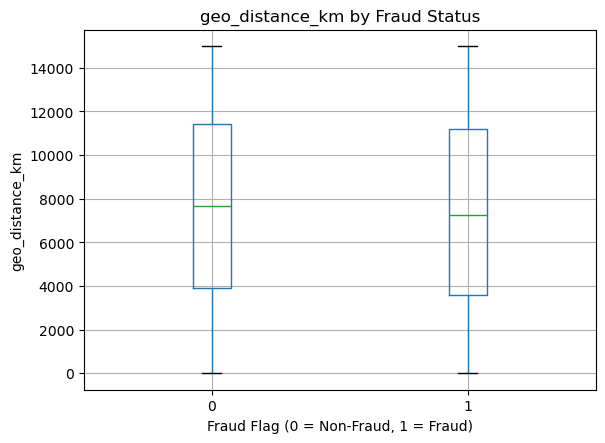

<Figure size 600x400 with 0 Axes>

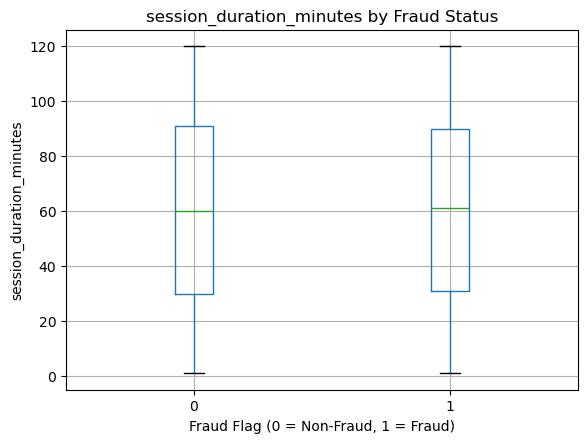

<Figure size 600x400 with 0 Axes>

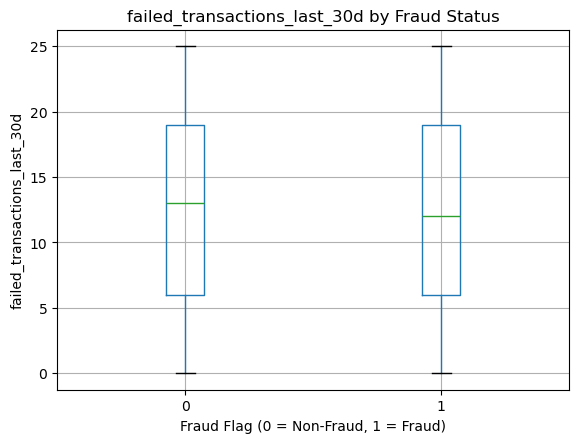

In [20]:
# Boxplots for important behavioral/risk variables

important_numeric = [
    "login_attempts",
    "device_risk_score",
    "transaction_velocity_score",
    "anomaly_score",
    "geo_distance_km",
    "session_duration_minutes",
    "failed_transactions_last_30d"
]

for col in important_numeric:
    if col in df_model.columns:
        plt.figure(figsize=(6,4))
        df_model.boxplot(column=col, by="fraud_flag")
        plt.title(f"{col} by Fraud Status")
        plt.suptitle("")
        plt.xlabel("Fraud Flag (0 = Non-Fraud, 1 = Fraud)")
        plt.ylabel(col)
        plt.show()

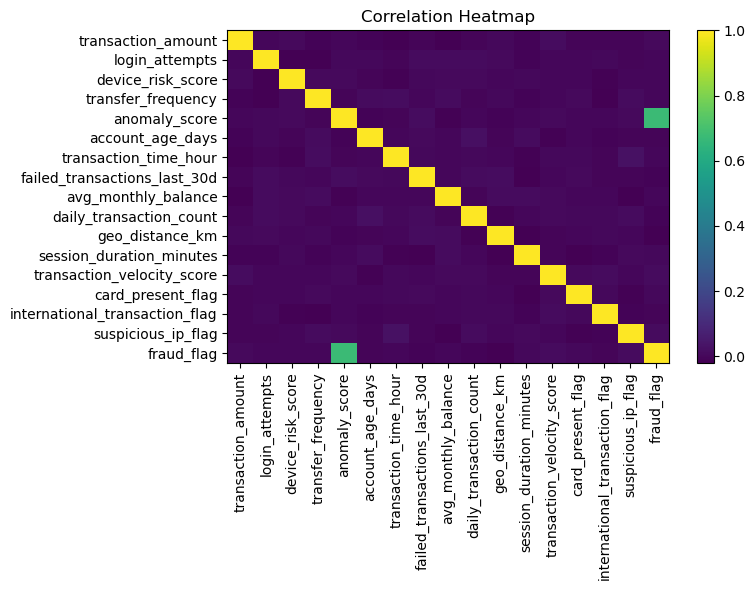

anomaly_score                     0.675
geo_distance_km                  -0.018
suspicious_ip_flag                0.010
transaction_velocity_score        0.010
daily_transaction_count          -0.009
failed_transactions_last_30d     -0.007
international_transaction_flag   -0.006
transaction_amount                0.005
account_age_days                 -0.005
session_duration_minutes          0.005
transfer_frequency               -0.003
avg_monthly_balance              -0.002
device_risk_score                -0.001
login_attempts                   -0.001
card_present_flag                 0.001
transaction_time_hour             0.000
Name: fraud_flag, dtype: float64

In [48]:
# Correlation heatmap for numeric variables

corr = df_model[numeric_cols + ["fraud_flag"]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Show variables most correlated with fraud
fraud_corr = corr["fraud_flag"].drop("fraud_flag").sort_values(key=abs, ascending=False)
display(fraud_corr)

## Machine Learning Models

The goal is to predict whether a transaction is fraudulent. Because fraud data can be imbalanced, the notebook evaluates models using precision, recall, F1-score, ROC-AUC, and confusion matrices instead of relying only on accuracy.

In [25]:
# Prepare features and target

X = df_model.drop(columns=["fraud_flag"])
y = df_model["fraud_flag"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training fraud rate:", y_train.mean())
print("Testing fraud rate:", y_test.mean())

Categorical columns: ['payment_channel', 'authentication_type']
Numeric columns: ['transaction_amount', 'login_attempts', 'device_risk_score', 'transfer_frequency', 'anomaly_score', 'account_age_days', 'transaction_time_hour', 'failed_transactions_last_30d', 'avg_monthly_balance', 'daily_transaction_count', 'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score', 'card_present_flag', 'international_transaction_flag', 'suspicious_ip_flag']
Training shape: (8000, 18)
Testing shape: (2000, 18)
Training fraud rate: 0.125125
Testing fraud rate: 0.125


In [27]:
# Preprocessing steps

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [29]:
# Define models

log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42
    ))
])

# scale_pos_weight helps XGBoost handle class imbalance
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1

xgb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb
}

Training Logistic Regression...

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1750
           1       0.64      0.94      0.76       250

    accuracy                           0.93      2000
   macro avg       0.81      0.93      0.86      2000
weighted avg       0.95      0.93      0.93      2000



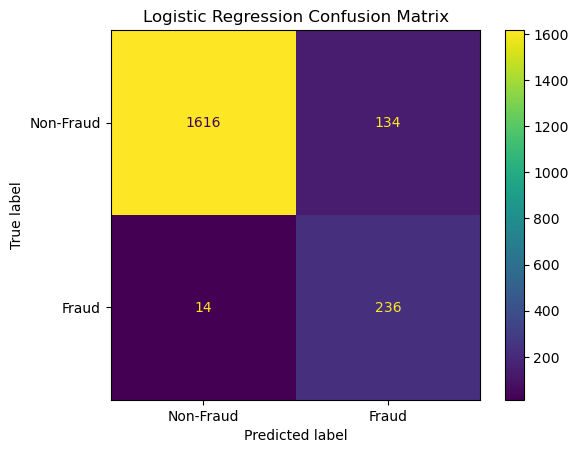

Training Random Forest...

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1750
           1       0.83      0.83      0.83       250

    accuracy                           0.96      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.96      0.96      0.96      2000



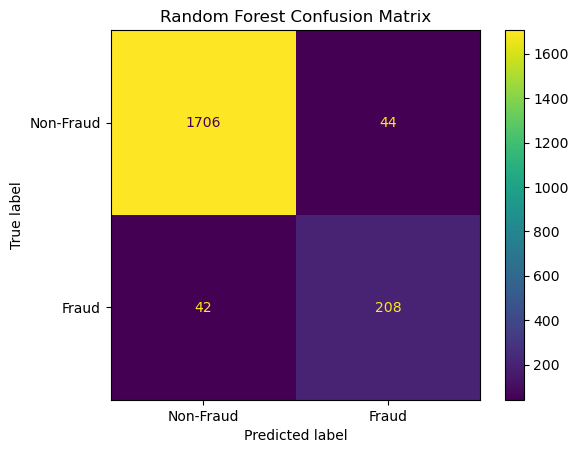

Training XGBoost...

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1750
           1       0.70      0.91      0.79       250

    accuracy                           0.94      2000
   macro avg       0.84      0.93      0.88      2000
weighted avg       0.95      0.94      0.94      2000



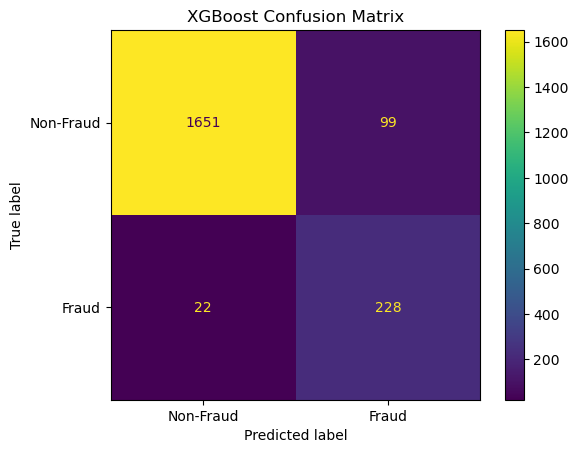

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.926,0.638,0.944,0.761,0.979
2,XGBoost,0.940,0.697,0.912,0.790,0.978
1,Random Forest,0.957,0.825,0.832,0.829,0.977


In [31]:
# Train and evaluate models

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
display(results_df)

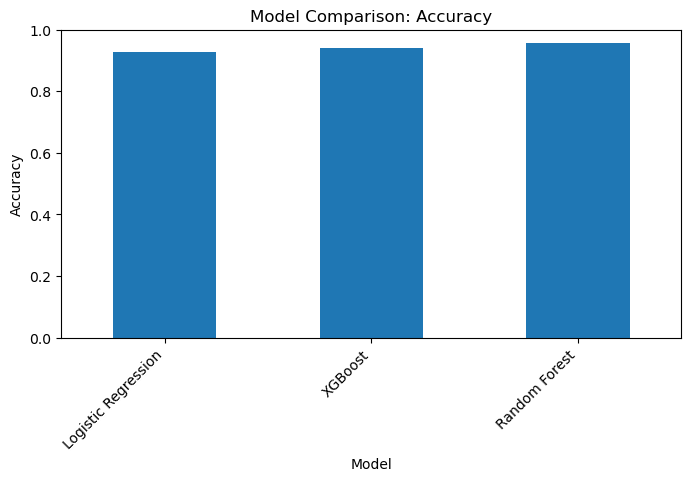

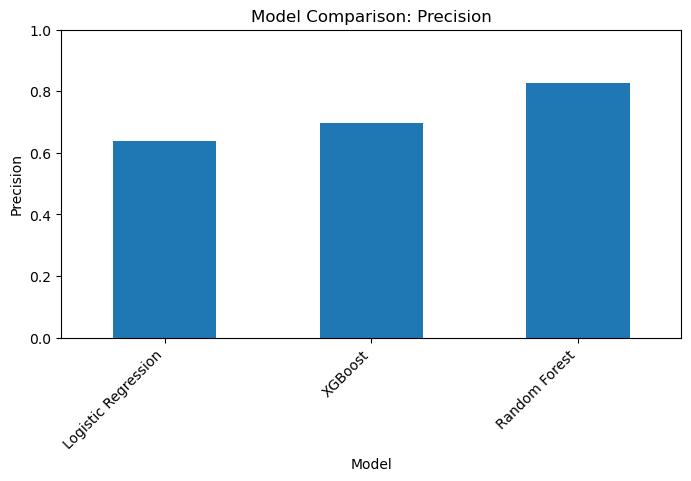

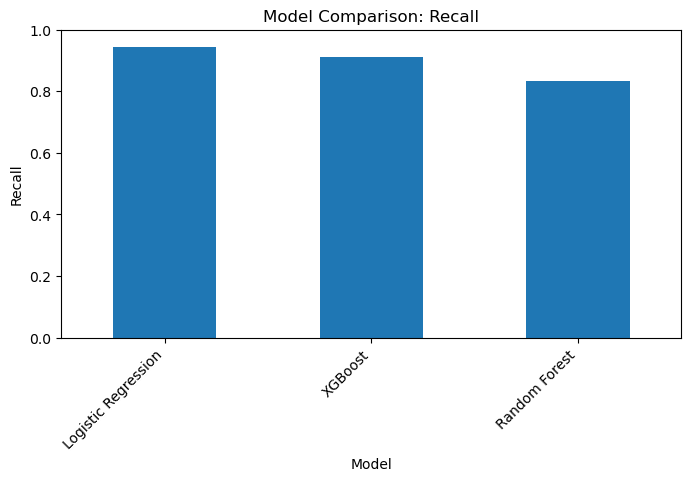

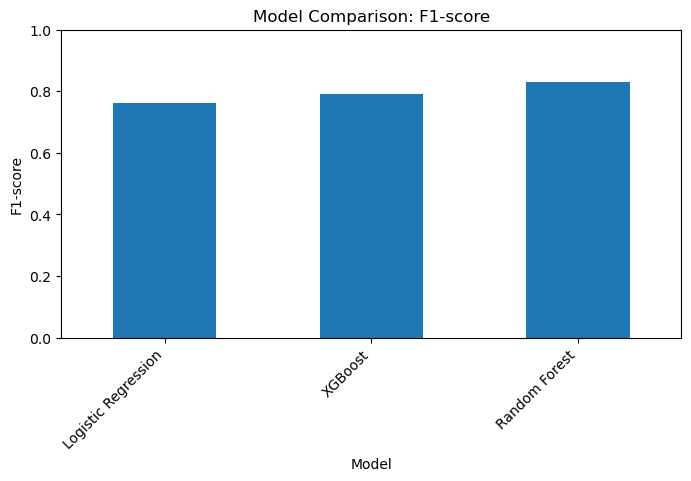

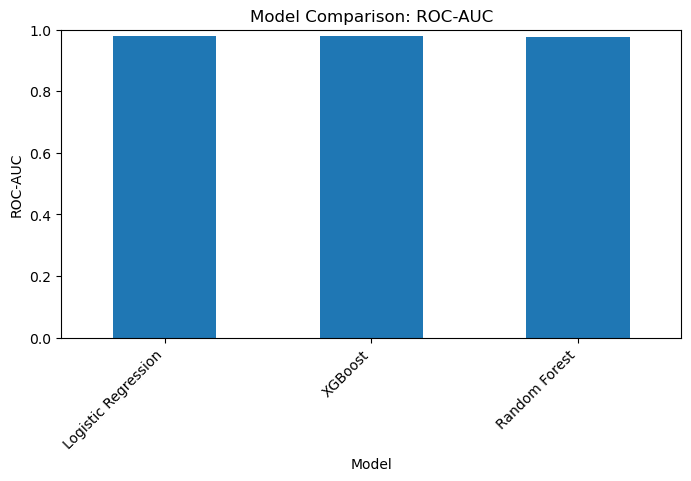

In [32]:
# Compare model performance visually

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

for metric in metrics:
    plt.figure(figsize=(8,4))
    results_df.set_index("Model")[metric].plot(kind="bar")
    plt.title(f"Model Comparison: {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.show()

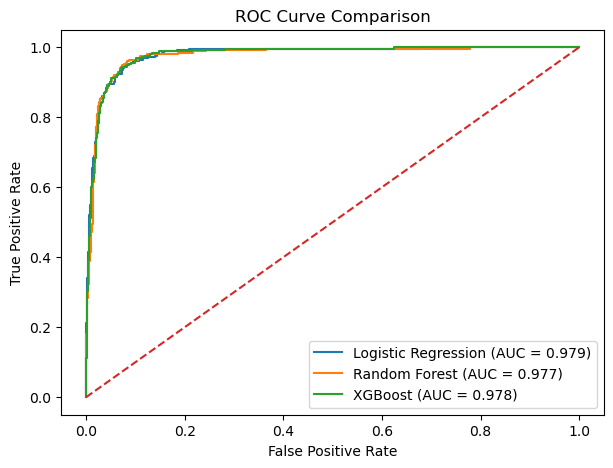

In [33]:
# ROC curves

plt.figure(figsize=(7,5))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Feature Importance

Feature importance helps explain which variables were most useful for predicting fraud risk. This is especially important because the project is not only about model accuracy, but also about understanding the business meaning behind fraud risk.

Best model based on ROC-AUC: Logistic Regression


,Feature,Importance
4,num__anomaly_score,3.852
20,cat__authentication_type_Biometric,0.301
16,cat__payment_channel_ATM,0.225
18,cat__payment_channel_POS Terminal,0.207
22,cat__authentication_type_Password Only,0.151
11,num__session_duration_minutes,0.138
10,num__geo_distance_km,0.124
5,num__account_age_days,0.121
9,num__daily_transaction_count,0.103
21,cat__authentication_type_OTP,0.100


<Figure size 900x500 with 0 Axes>

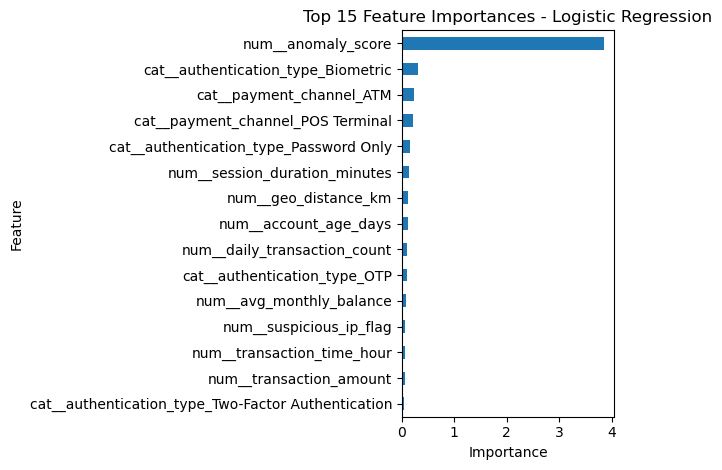

In [36]:
# Get feature names after preprocessing

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

# Feature importance works directly for Random Forest and XGBoost
if best_model_name in ["Random Forest", "XGBoost"]:
    importances = best_model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

# Logistic Regression uses coefficient size as importance
else:
    coefficients = best_model.named_steps["model"].coef_[0]
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": np.abs(coefficients)
    }).sort_values("Importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(9,5))
importance_df.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)
plt.title(f"Top 15 Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Business-Focused Result Summary

Use the cells below after running the notebook to help write the Analysis and Conclusion sections of the white paper.

In [41]:
# Automatically generate a short result summary

best = results_df.iloc[0]

print("RESULT SUMMARY")
print("--------------")
print(f"The best-performing model based on ROC-AUC was {best['Model']}.")
print(f"ROC-AUC: {best['ROC-AUC']:.3f}")
print(f"Precision: {best['Precision']:.3f}")
print(f"Recall: {best['Recall']:.3f}")
print(f"F1-score: {best['F1-score']:.3f}")

print("\nTop fraud-related correlations:")
display(fraud_corr.head(10))

print("\nTop model features:")
display(importance_df.head(10))

RESULT SUMMARY
--------------
The best-performing model based on ROC-AUC was Logistic Regression.
ROC-AUC: 0.979
Precision: 0.638
Recall: 0.944
F1-score: 0.761

Top fraud-related correlations:


anomaly_score                     0.675
geo_distance_km                  -0.018
suspicious_ip_flag                0.010
transaction_velocity_score        0.010
daily_transaction_count          -0.009
failed_transactions_last_30d     -0.007
international_transaction_flag   -0.006
transaction_amount                0.005
account_age_days                 -0.005
session_duration_minutes          0.005
Name: fraud_flag, dtype: float64


Top model features:


,Feature,Importance
4,num__anomaly_score,3.852
20,cat__authentication_type_Biometric,0.301
16,cat__payment_channel_ATM,0.225
18,cat__payment_channel_POS Terminal,0.207
22,cat__authentication_type_Password Only,0.151
11,num__session_duration_minutes,0.138
10,num__geo_distance_km,0.124
5,num__account_age_days,0.121
9,num__daily_transaction_count,0.103
21,cat__authentication_type_OTP,0.100


In [46]:
# Save key outputs

results_df.to_csv("model_results_summary.csv", index=False)
fraud_corr.to_csv("fraud_correlation_results.csv")
importance_df.to_csv("feature_importance_results.csv", index=False)

print("Saved result files:")
print("- model_results_summary.csv")
print("- fraud_correlation_results.csv")
print("- feature_importance_results.csv")

Saved result files:
- model_results_summary.csv
- fraud_correlation_results.csv
- feature_importance_results.csv
